In [393]:
import os
print(os.listdir('/content'))

['.config', 'archive.zip', 'malaria_dataset', 'sample_data']


In [394]:
import zipfile
import os

zip_path = '/content/archive.zip'
extract_path = '/content/malaria_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['Dataset']


In [395]:
import os

dataset_path = '/content/malaria_dataset/Dataset'

print(os.listdir(dataset_path))

['Train', 'Test']


In [396]:
import os
train_path = '/content/malaria_dataset/Dataset/Train'
print(os.listdir(train_path))

['Uninfected', 'Parasite']


In [397]:
import os

train_path = '/content/malaria_dataset/Dataset/Train'

parasite_path = os.path.join(train_path, 'Parasite')
uninfected_path = os.path.join(train_path, 'Uninfected')

print("Parasite images:",
      len(os.listdir(parasite_path)))

print("Uninfected images:",
      len(os.listdir(uninfected_path)))

Parasite images: 220
Uninfected images: 196


Image name: C134P95ThinF_IMG_20151005_121952_cell_120.png
Original image size: (118, 127)
Image mode: RGB


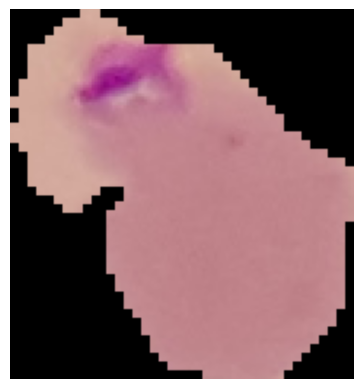

In [398]:
from PIL import Image
import os
import matplotlib.pyplot as plt

image_folder = '/content/malaria_dataset/Dataset/Train/Parasite'

image_name = os.listdir(image_folder)[0]
image_path = os.path.join(image_folder, image_name)

image = Image.open(image_path)

print("Image name:", image_name)
print("Original image size:", image.size)
print("Image mode:", image.mode)

plt.imshow(image)
plt.axis('off')
plt.show()

Original size: (118, 127)
Resized size: (128, 128)


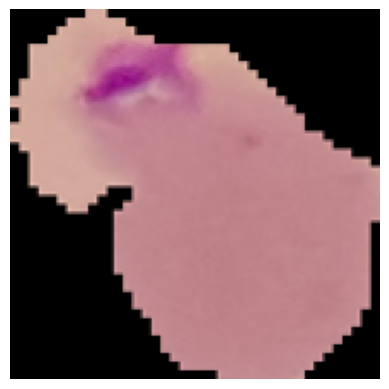

In [399]:
from PIL import Image

# Resize image
resized_image = image.resize((128, 128))

print("Original size:", image.size)
print("Resized size:", resized_image.size)

# Display resized image
plt.imshow(resized_image)
plt.axis('off')
plt.show()

In [400]:
import numpy as np

# Convert resized image into NumPy array
image_array = np.array(resized_image)

# Normalize pixel values (0 to 1)
normalized_image = image_array / 255.0

print("Original pixel range:",
      image_array.min(), "to", image_array.max())

print("Normalized pixel range:",
      normalized_image.min(), "to", normalized_image.max())

print("Image shape:", normalized_image.shape)

Original pixel range: 0 to 242
Normalized pixel range: 0.0 to 0.9490196078431372
Image shape: (128, 128, 3)


In [401]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset path
train_path = '/content/malaria_dataset/Dataset/Train'

# Image preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data generator
train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

# Validation data generator
validation_generator = datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

print("Preprocessing pipeline created!")
print("Class labels:", train_generator.class_indices)

Found 333 images belonging to 2 classes.
Found 83 images belonging to 2 classes.
Preprocessing pipeline created!
Class labels: {'Parasite': 0, 'Uninfected': 1}


In [402]:
# Get one batch of preprocessed images
images, labels = next(train_generator)

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

print("Pixel minimum:", images.min())
print("Pixel maximum:", images.max())

Batch image shape: (32, 128, 128, 3)
Batch label shape: (32,)
Pixel minimum: 0.0
Pixel maximum: 0.9960785


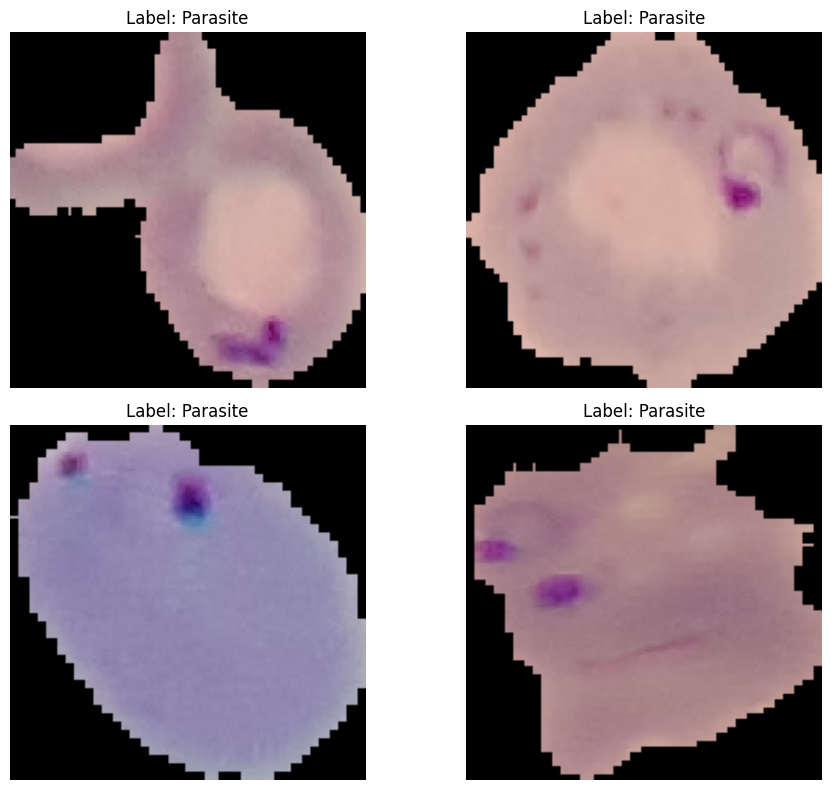

In [403]:
import matplotlib.pyplot as plt

# Display 4 preprocessed images
plt.figure(figsize=(10, 8))

for i in range(4):
    plt.subplot(2, 2, i + 1)

    # Display image
    plt.imshow(images[i])

    # Convert label to class name
    label = int(labels[i])
    class_name = list(train_generator.class_indices.keys())[label]

    plt.title(f"Label: {class_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [404]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def preprocess_image_dataset(
    dataset_path,
    image_size=(128, 128),
    batch_size=32,
    validation_split=0.2
):
    """
    Reusable image preprocessing pipeline.

    Parameters:
    dataset_path: Dataset folder path
    image_size: Target image size
    batch_size: Number of images per batch
    validation_split: Validation data percentage

    Returns:
    train_generator, validation_generator
    """

    datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=validation_split
    )

    train_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=image_size,
        batch_size=batch_size,
        class_mode='binary',
        subset='training',
        shuffle=True
    )

    validation_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=image_size,
        batch_size=batch_size,
        class_mode='binary',
        subset='validation',
        shuffle=False
    )

    return train_generator, validation_generator


# Example: Malaria Dataset
train_generator, validation_generator = preprocess_image_dataset(
    dataset_path='/content/malaria_dataset/Dataset/Train',
    image_size=(128, 128),
    batch_size=32
)

print("Reusable preprocessing pipeline ready!")
print("Class labels:", train_generator.class_indices)

Found 333 images belonging to 2 classes.
Found 83 images belonging to 2 classes.
Reusable preprocessing pipeline ready!
Class labels: {'Parasite': 0, 'Uninfected': 1}


In [405]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("Imports successful!")

Imports successful!


In [406]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu'
    )
])

print("Convolution Layer 1 created!")

Convolution Layer 1 created!


In [407]:
model.add(layers.MaxPooling2D(pool_size=(2,2)))
print("Max Pooling Layer 1 created!")

Max Pooling Layer 1 created!


In [408]:
model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation = 'relu'))
print("Convolution Layer 2 created!")

Convolution Layer 2 created!


In [409]:
model.add(layers.MaxPooling2D(pool_size=(2,2)))
print("Max Pooling Layer 2 created!")

Max Pooling Layer 2 created!


In [410]:
model.add(layers.Flatten())
print("Flatten Layer created!")

Flatten Layer created!


In [411]:
model.add(layers.Dense(units=128, activation='relu'))
print("Dense Layer created!")

Dense Layer created!


In [412]:
model.add(layers.Dense(units=1, activation='sigmoid'))
print("Output Layer created!")

Output Layer created!


In [413]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Model compiled successfully!")

Model compiled successfully!


In [414]:
model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [415]:
history=model.fit(train_generator, validation_data=validation_generator, epochs=10)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5345 - loss: 0.9505 - val_accuracy: 0.5301 - val_loss: 0.6121
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 962ms/step - accuracy: 0.6847 - loss: 0.5942 - val_accuracy: 0.6627 - val_loss: 0.5393
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 793ms/step - accuracy: 0.7628 - loss: 0.4783 - val_accuracy: 0.7349 - val_loss: 0.5293
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 965ms/step - accuracy: 0.8078 - loss: 0.3944 - val_accuracy: 0.8072 - val_loss: 0.4799
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 953ms/step - accuracy: 0.9069 - loss: 0.2727 - val_accuracy: 0.7952 - val_loss: 0.5037
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 868ms/step - accuracy: 0.8859 - loss: 0.2373 - val_accuracy: 0.7952 - val_loss: 0.5922
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 867ms/step - accuracy: 0.9730 - loss: 0.1304 - val_accuracy: 0.7590 - val_loss: 0.7156
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 955ms/step - accuracy: 0.9820 - loss: 0.0747 - val_accuracy:

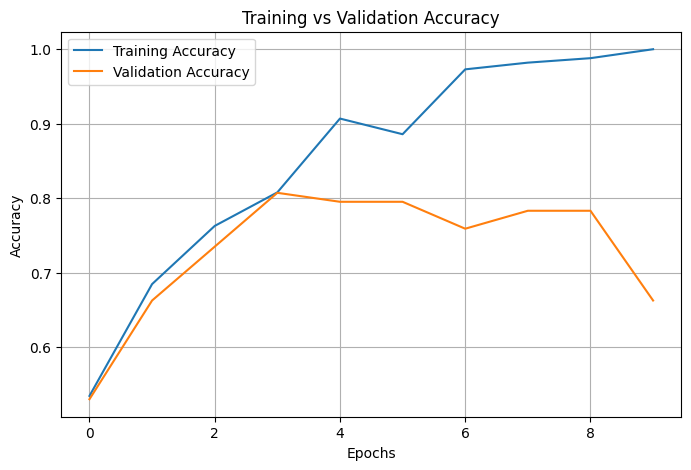

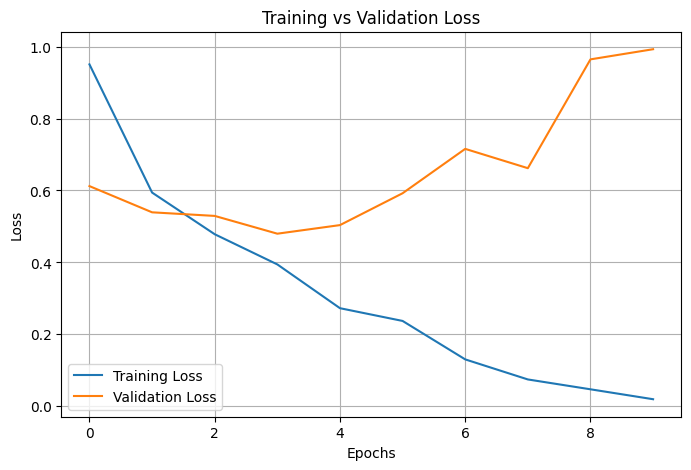

In [416]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# Loss Graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [417]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/malaria_dataset/Dataset/Test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

print("Test generator created!")
print("Class labels:", test_generator.class_indices)

Found 134 images belonging to 2 classes.
Test generator created!
Class labels: {'Parasite': 0, 'Uninfected': 1}


In [418]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy * 100, "%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.5672 - loss: 1.2365
Test Loss: 1.2364699840545654
Test Accuracy: 56.71641826629639 %


In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

# Upload an image
uploaded = files.upload()

# Get uploaded image name
image_name = list(uploaded.keys())[0]

# Load and resize image
img = load_img(
    image_name,
    target_size=(128, 128)
)

# Convert image to array
img_array = img_to_array(img)

# Normalize pixel values
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)[0][0]

# Interpret prediction according to class labels
if prediction >= 0.5:
    result = "Uninfected"
else:
    result = "Parasite"

print("Prediction Probability:", prediction)
print("Predicted Class:", result)